In [3]:
from google.colab import files
uploaded = files.upload()

Saving student_placement_synthetic.csv to student_placement_synthetic (1).csv


In [4]:
import pandas as pd

df = pd.read_csv('student_placement_synthetic.csv')
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


In [ ]:
df.isnull().sum()

,0
branch,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
dsa_score,0
aptitude_score,0
communication_skills,0
ml_knowledge,0
system_design,0


In [12]:
df['salary_package_lpa'].fillna(0, inplace=True)

/tmp/ipykernel_808/1000067225.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary_package_lpa'].fillna(0, inplace=True)


In [13]:
df = pd.get_dummies(df, drop_first=True)

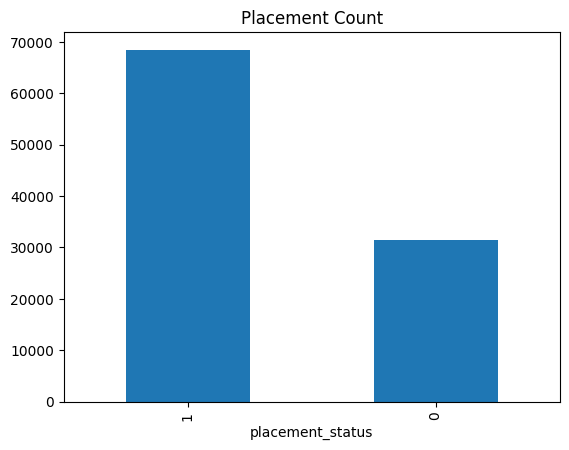

In [14]:
import matplotlib.pyplot as plt

df['placement_status'].value_counts().plot(kind='bar')
plt.title("Placement Count")
plt.show()

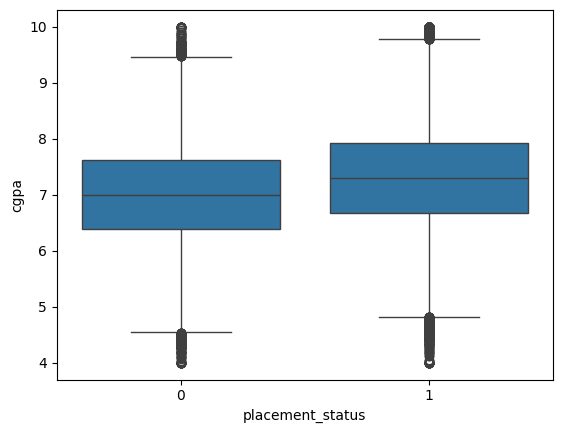

In [15]:
import seaborn as sns

sns.boxplot(x='placement_status', y='cgpa', data=df)
plt.show()

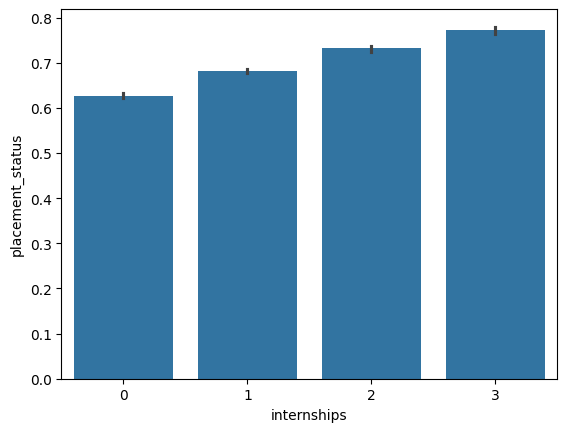

In [16]:
sns.barplot(x='internships', y='placement_status', data=df)
plt.show()

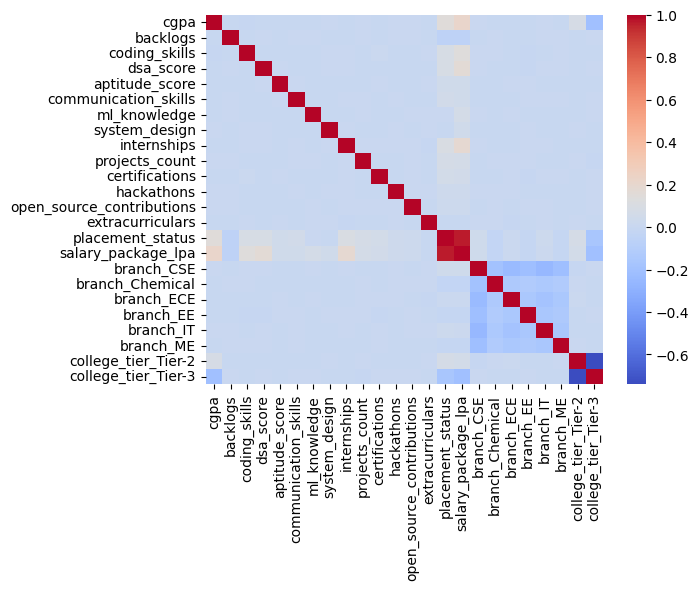

In [17]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [18]:
Students with higher DSA score & coding skills are more likely placed
Internships + Projects significantly increase placement chances
Communication skills also play a key role

SyntaxError: invalid syntax (3650039612.py, line 1)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop('placement_status', axis=1)
y = df['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [20]:
import numpy as np

importance = model.coef_[0]
features = X.columns

for i in range(len(features)):
    print(features[i], ":", importance[i])

cgpa : -0.1100331910753597
backlogs : -0.02902206790863086
coding_skills : -0.1268118693117514
dsa_score : -0.1313172146089878
aptitude_score : -0.12838369546102063
communication_skills : -0.08581938164960341
ml_knowledge : -0.1131702177277258
system_design : -0.09697603930287382
internships : -0.01869467637680065
projects_count : -0.028151572813396388
certifications : -0.0017387495391037746
hackathons : -0.007688773264978023
open_source_contributions : -0.0010611687794139194
extracurriculars : -0.026030437720076575
salary_package_lpa : 2.0640896975022924
branch_CSE : -0.002239104287039438
branch_Chemical : -0.0059675498854793235
branch_ECE : 0.0007121429524904749
branch_EE : -0.004704897964715555
branch_IT : 0.00441251923011726
branch_ME : -0.004753554536747771
college_tier_Tier-2 : 0.002943052055548089
college_tier_Tier-3 : -0.0258559476849291


In [11]:
DSA score is the most important factor
CGPA has strong positive impact
Internships significantly improve placement chances
Communication skills also contribute

SyntaxError: invalid syntax (795101316.py, line 1)

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 6288     0]
 [    0 13712]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6288
           1       1.00      1.00      1.00     13712

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [22]:
df.to_csv("placement_cleaned.csv", index=False)

In [5]:
from google.colab import files
files.download('student_placement_synthetic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
files.download('placement_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
files.download('placement_model.pkl')

FileNotFoundError: Cannot find file: placement_model.pkl

In [24]:
import os
os.listdir()

['.config',
 'student_placement_synthetic (1).csv',
 'student_placement_synthetic.csv',
 'placement_cleaned.csv',
 'sample_data']

In [25]:
import pickle

with open('placement_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [26]:
from google.colab import files
files.download('placement_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>